In [1]:
import snappy
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from invariants import *

### TODO
- write a function to draw wedge regions for different invariants in the $e$-$b_1$ plane
- when $\sigma$ and $\upsilon$ are different, draw wedge regions for $T(4,q)$ in the $e$-$b_1$ plane
- For $T(4,5)$ try to find 2 band moves to the unknot ($\gamma_4(T(4,5)) = 2$ so we need exactly two bands) and compute their normal euler number and upsilon to place them in the wedge plot

# Plot Knot Geography $T(p,q)$
Gordon-Litherland signature bound:
$$
W_\sigma = \left\{
2b \ge \left| e - 2\sigma(K) \right|
\right\}
$$

In [2]:
def plot_sig_bound(K, erange=(-30,30), brange=(0,30),
                   resolution=300, fig=None, ax=None,
                   plot_points=False, show_grid=True):
    if fig is None and ax is None:
        fig, ax = plt.subplots()
    
    sigma = K.signature()

    # integer points
    if plot_points:
        int_points = [(e,b) 
                      for e in range(erange[0], erange[1]+1) 
                      for b in range(brange[0], brange[1]+1)]
        realizable_points = [(e,b) for e,b in int_points if 2*b >= abs(e - 2 * sigma)]
        realizable_e = [e for e,_ in realizable_points]
        realizable_b = [b for _,b in realizable_points]

        ax.scatter(realizable_e, realizable_b, s=0.5, c='red')
    
    # signature bound
    es = np.linspace(erange[0], erange[1], resolution)
    bs = np.linspace(brange[0], brange[1], resolution)
    e,b = np.meshgrid(es, bs)

    ax.imshow(2 * b >= abs(e - 2 * sigma),
              extent=(erange[0],erange[1],brange[0],brange[1]), origin='lower',
              cmap='Greys', alpha=0.2)
    
    bound_line = 0.5 * abs(es - 2 * sigma)
    ax.plot(es, bound_line, label=f"$2b_1\\geq |e-2\\sigma|$, $\\sigma={sigma}$")

    plt.title(f"Signature bound, $\\sigma={sigma}$")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.xlim(erange[0], erange[1])
    plt.ylim(brange[0], brange[1])
    plt.xlabel(r'$e$')
    plt.ylabel(r'$b_1$')

    ax.xaxis.set_minor_locator(ticker.MultipleLocator(base=1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(base=5))

    if show_grid:
        ax.minorticks_on()
        plt.grid(which='minor', linewidth=0.25)
        plt.grid(which='major', linewidth=0.5)
    else:
        plt.grid(False)
        
    return fig, ax, sigma

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Signature bound, $\\sigma=-8$'}, xlabel='$e$', ylabel='$b$'>,
 -8)

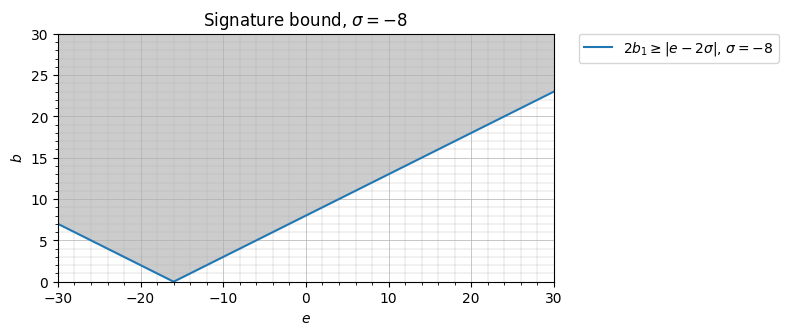

In [3]:
T45 = snappy.Link('T(4,5)')
plot_sig_bound(T45)

### $\Upsilon(1)$ bound
Per [Allen](https://arxiv.org/pdf/2007.14332):
$$
    b_1 \ge \left| 2\Upsilon(1) - \frac{e}{2} \right|
$$

In [4]:
def plot_upsilon_bound(K, erange=[-30,30], brange=[0,30],
                       resolution=300, fig=None, ax=None,
                       plot_points=False, show_grid=True):
    if fig is None and ax is None:
        fig, ax = plt.subplots()
    
    ups = upsilon(K)
    
    # integer points
    if plot_points:
        int_points = [(e,b) 
                      for e in range(erange[0], erange[1]+1) 
                      for b in range(brange[0], brange[1]+1)]
        realizable_points = [(e,b) for e,b in int_points if b >= abs(2 * ups - 0.5 * e)]
        realizable_e = [e for e,_ in realizable_points]
        realizable_b = [b for _,b in realizable_points]
        ax.scatter(realizable_e, realizable_b, s=0.5, c='red')

    # upsilon bound
    es = np.linspace(erange[0], erange[1], resolution)
    bs = np.linspace(brange[0], brange[1], resolution)
    e,b = np.meshgrid(es, bs)

    ax.imshow(b >= abs(2 * ups - 0.5 * e),
              extent=(erange[0],erange[1],brange[0],brange[1]), origin='lower',
              cmap='Greys', alpha=0.2)

    bound_line = abs(2 * ups - 0.5 * es)
    ax.plot(es, bound_line, label="$b_1\\geq \\left|2\\Upsilon(1)-\\frac{e}{2}\\right|$, "+f"$\\Upsilon(1)={ups}$")

    plt.title(f"$\\Upsilon(1)$ bound, $\\Upsilon={ups}$")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.xlim(erange[0], erange[1])
    plt.ylim(brange[0], brange[1])
    plt.xlabel(r'$e$')
    plt.ylabel(r'$b_1$')

    ax.xaxis.set_minor_locator(ticker.MultipleLocator(base=1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(base=5))

    if show_grid:
        ax.minorticks_on()
        plt.grid(which='minor', linewidth=0.25)
        plt.grid(which='major', linewidth=0.5)
    else:
        plt.grid(False)
    
    return fig, ax, ups

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': '$\\Upsilon(1)$ bound, $\\Upsilon=-4$'}, xlabel='$e$', ylabel='$b$'>,
 -4)

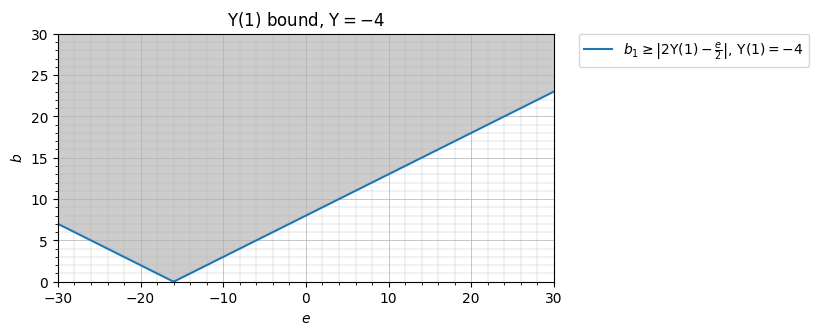

In [5]:
plot_upsilon_bound(T45)

## Put them together!
The bounds are different if and only if $\sigma \ne 2\Upsilon$.
If they're different then there is an intersection at $(e,b) = \left(2\Upsilon+\sigma,~\Upsilon-\frac{\sigma}{2}\right)$.

In [6]:
def plot_bounds(K, erange=(-40,40), brange=(0,30),
                resolution=300, show_grid=True):
    fig, ax = plt.subplots()
    fig, ax, sig = plot_sig_bound(K, erange=erange, brange=brange, resolution=resolution, fig=fig, ax=ax)
    fig, ax, ups = plot_upsilon_bound(K, erange=erange, brange=brange, resolution=resolution, fig=fig, ax=ax)

    # if signature/upsilon bounds are different, find their intersection point
    if (sig != 2 * ups):
        e_int = 2 * ups + sig
        b_int = int(ups - 0.5 * sig)
        ax.scatter([e_int], [b_int],
                marker='o', color='red', s=8, zorder=10,
                label=r"$\left(2\Upsilon+\sigma,\Upsilon-\frac{\sigma}{2}\right)=" + f'({e_int},{b_int})' + r'$')
        
    
    plt.title("$b_1$ bounds")
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

    if show_grid:
        ax.minorticks_on()
        plt.grid(which='minor', linewidth=0.25)
        plt.grid(which='major', linewidth=0.5)
    else:
        plt.grid(False)

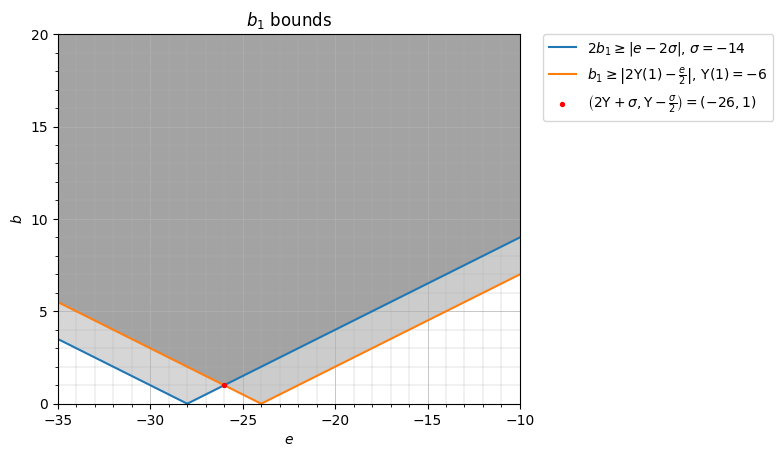

In [7]:
T47 = snappy.Link('T(4,7)')
plot_bounds(T47, erange=(-35,-10), brange=(0,20))

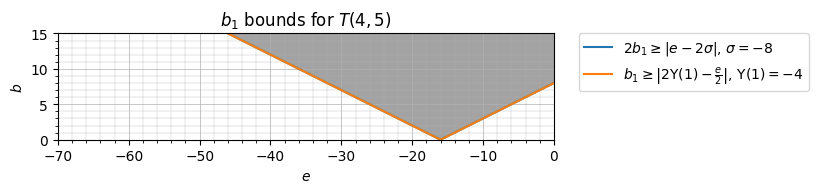

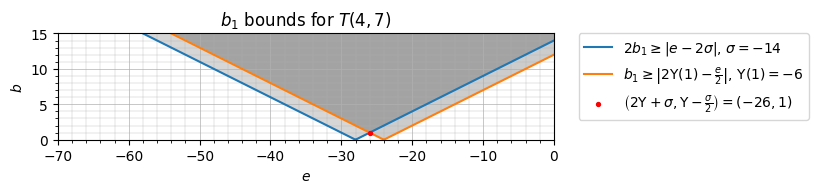

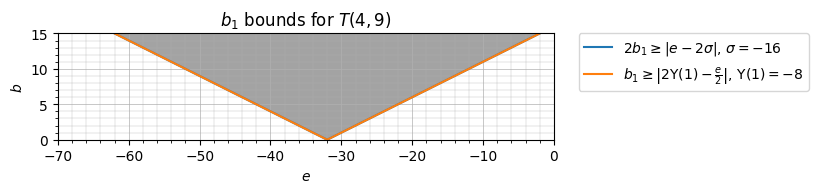

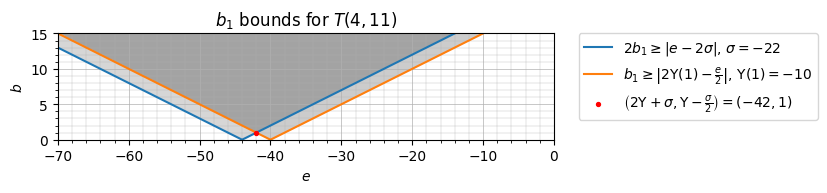

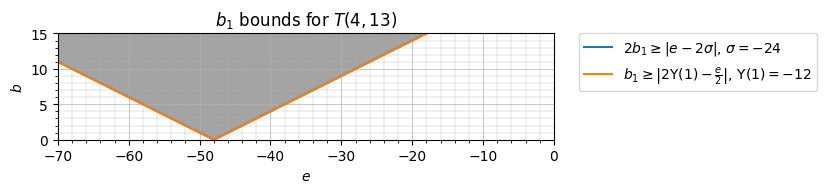

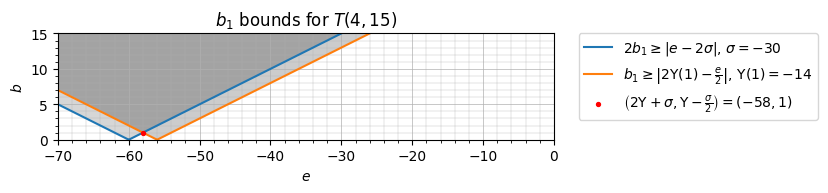

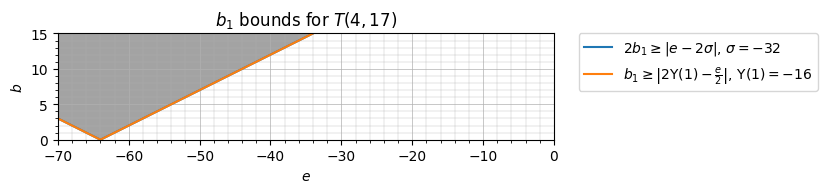

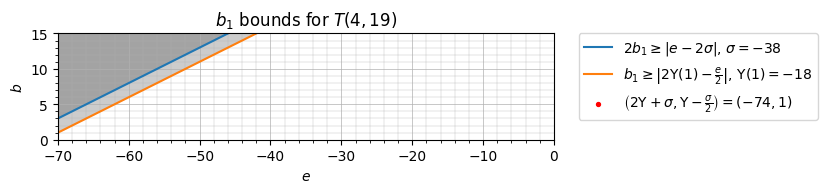

In [8]:
for q in range(5,20):
    if math.gcd(4,q) != 1:
        continue

    T4q = snappy.Link(f'T(4,{q})')
    plot_bounds(T4q, erange=(-70,0), brange=(0,15))
    
    plt.title(f"$b_1$ bounds for $T(4,{q})$")
    plt.show()